In [1]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, Input

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
def predict_and_evaluate(model, features, labels, threeshold = 0.5):

  pred_proba = model.predict(features)
  pred_positive = pred_proba[:, 1]
  pred = np.where(pred_positive > threeshold, 1, 0)
  bal_acc = balanced_accuracy_score(labels, pred)

  print('=='*10)
  print(f'Balanced Accuracy: {bal_acc}')
  print('=='*10)

  report = classification_report(labels, pred, zero_division=0)
  print(report)
  plot_confusion_matrix(labels, pred, ['benigna', 'maligna'], 2)


  return pred_proba, pred, bal_acc, report

In [4]:
def plot_roc_curve(true: np.ndarray, pred: np.ndarray):
    prob_positive = pred[:, 1]

    fpr, tpr, thresholds = roc_curve(true, prob_positive)
    roc_auc = auc(fpr, tpr)

    j_scores = tpr - fpr
    j_index = np.argmax(j_scores)

    optimal_threshold = thresholds[j_index]
    plt.figure(figsize=(8, 6))

    # Curva do Modelo
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Curva ROC (AUC = {roc_auc:.4f})')

    # Linha de classificação aleatória
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório')

    # Ponto do threshold ideal
    plt.plot(fpr[j_index], tpr[j_index], 'ro', markersize=8,
             label=f'Threshold Ideal ({optimal_threshold:.4f})')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
    plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
    plt.title('Curva ROC e Threshold Ótimo para Classificador de Melanoma')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return optimal_threshold, roc_auc

In [5]:

IMAGE_SIZE = (224, 224)

def load_and_preprocess(file_path, label):
    """
    Função para carregar a aplicar pré processamento básico em uma imagem.
    Transformação da imagem em tensor e redimensionamento.
    """
    image_binary = tf.io.read_file(file_path)
    image_tf = tf.image.decode_jpeg(image_binary, channels=3)
    image = tf.image.resize(image_tf, IMAGE_SIZE)

    # EfficientNet espera pixels entre [0, 255], então APENAS converta para float
    image = tf.cast(image, tf.float32)

    return image, label

In [6]:

def augment_data(image, label):
    """
    Função que aplica transformações aleatórias (Data Augmentation) na imagem.
    """
    # Flips e transformações de cor
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    return image, label


In [7]:
BATCH_SIZE = 128
BASE_DIR = '/content/drive/MyDrive/MDC_data/images/'

In [8]:
# Carregamento o dataframe de rótulos e criação do conjunto de dados como
# Dataset para obter performance otimizada de processamento

train_info = pd.read_csv("/content/drive/MyDrive/MDC_data/train.csv")

train_file_paths = [os.path.join(BASE_DIR, f'{img_path}') for img_path in train_info['path']]

y_train = train_info['target'].values

train_path_ds = tf.data.Dataset.from_tensor_slices((tf.constant(train_file_paths), tf.constant(y_train)))
train_images_ds = train_path_ds.map(load_and_preprocess,
                       num_parallel_calls=tf.data.AUTOTUNE)
train_images_ds_augmented = train_images_ds.shuffle(buffer_size=1024).map(
    augment_data,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_batches = train_images_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
train_batches_augmented = train_images_ds_augmented.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [9]:
val_info = pd.read_csv("/content/drive/MyDrive/MDC_data/val.csv")

val_file_paths = [os.path.join(BASE_DIR, f'{img_path}') for img_path in val_info['path']]

y_val = val_info['target'].values

val_path_ds = tf.data.Dataset.from_tensor_slices((tf.constant(val_file_paths), tf.constant(y_val)))
val_images_ds = val_path_ds.map(load_and_preprocess,
                       num_parallel_calls=tf.data.AUTOTUNE)

val_batches = val_images_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [10]:
def load_and_preprocess_test(file_path):
    """
    Função para carregar a aplicar pré processamento básico em uma imagem.
    Transformação da imagem em tensor e redimensionamento.
    """
    image_binary = tf.io.read_file(file_path)
    image_tf = tf.image.decode_jpeg(image_binary, channels=3)
    image = tf.image.resize(image_tf, IMAGE_SIZE)

    # EfficientNet espera pixels entre [0, 255], então APENAS converta para float
    image = tf.cast(image, tf.float32)
    # image = tf.cast(image, tf.float32) / 255.0

    return image

In [11]:
def plot_confusion_matrix(y_true, y_pred, class_names, NUM_CLASSES=4):
  cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES))).astype("float")
  cm = cm / cm.sum(axis=1, keepdims=True)

  plt.figure(figsize=(6,5))
  sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=True,
        linewidths=.5,
        linecolor='black'
    )

  plt.title("Matriz de Confusão Normalizada")
  ticks = np.arange(NUM_CLASSES)
  plt.xticks(ticks + 0.5, class_names, rotation=45, ha="right")
  plt.yticks(ticks + 0.5, class_names, rotation=0)
  plt.ylabel("Verdadeiro")
  plt.xlabel("Predito")
  plt.tight_layout()
  plt.show()

In [12]:
classes = np.unique(y_train)


weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

In [19]:
# base_model = tf.keras.applications.ResNet50(weights = 'imagenet', include_top = False, input_shape = (224, 224, 3))
base_model = tf.keras.applications.EfficientNetB0(weights ='imagenet', include_top=False, input_shape=(224, 224, 3))


base_model.trainable = True
# 2. CONGELAR completamente a base (Feature Extraction puro)
# base_model.trainable = False

# Congelamento de todas camadas
#for layer in model.layers:
#    layer.trainable = False
# #Congelamento de n camadas
for layer in base_model.layers[:-40]:
    layer.trainable = False

model = tf.keras.Sequential([base_model,
                              tf.keras.layers.GlobalAveragePooling2D (),
                              Dropout(rate=0.3),
                              Dense(2, activation = 'softmax')])

input_shape = (None, 224, 224, 3)
model.build(input_shape=input_shape)
model.summary ()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,052,133 (15.46 MB)

 Trainable params: 2,053,266 (7.83 MB)

 Non-trainable params: 1,998,867 (7.63 MB)

In [24]:
import keras

#SGD
sgd = tf.keras.optimizers.SGD(learning_rate = 0.001, momentum = 0.9, decay = 0.001)

#Adam
learning_rate = 1e-5 # Uso de baixa taxa de aprendizado
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

#Early stopping
early = tf.keras.callbacks.EarlyStopping (monitor = 'val_loss', patience = 5, restore_best_weights = True)
f1_score = keras.metrics.F1Score(average = 'macro')

# Compila o modelo (assumindo que 'frozen_model' está definido).
model.compile (loss = 'sparse_categorical_crossentropy', optimizer = optimizer, metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [25]:
n_epochs = 10
model.fit(train_batches_augmented,
          epochs = n_epochs,
          class_weight = class_weights,
          validation_data = val_batches)


Epoch 1/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 81s 323ms/step - accuracy: 0.9519 - loss: 0.1238 - val_accuracy: 0.8872 - val_loss: 0.3762
Epoch 2/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 28s 167ms/step - accuracy: 0.9579 - loss: 0.1036 - val_accuracy: 0.8880 - val_loss: 0.3603
Epoch 3/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 28s 169ms/step - accuracy: 0.9612 - loss: 0.0940 - val_accuracy: 0.8872 - val_loss: 0.3528
Epoch 4/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 28s 169ms/step - accuracy: 0.9676 - loss: 0.0822 - val_accuracy: 0.8888 - val_loss: 0.3496
Epoch 5/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 28s 168ms/step - accuracy: 0.9654 - loss: 0.0906 - val_accuracy: 0.8900 - val_loss: 0.3488
Epoch 6/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 28s 167ms/step - accuracy: 0.9699 - loss: 0.0894 - val_accuracy: 0.8892 - val_loss: 0.3472
Epoch 7/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 28s 166ms/step - accuracy: 0.9702 - loss: 0.0785 - val_accuracy: 0.8892 - val_loss: 0.3474
Epoch 8/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 28s 168ms/step - accuracy: 0.9694 - loss: 0

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 472ms/step
Balanced Accuracy: 0.8373272665992585
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      2070
           1       0.66      0.76      0.70       430

    accuracy                           0.89      2500
   macro avg       0.80      0.84      0.82      2500
weighted avg       0.90      0.89      0.89      2500



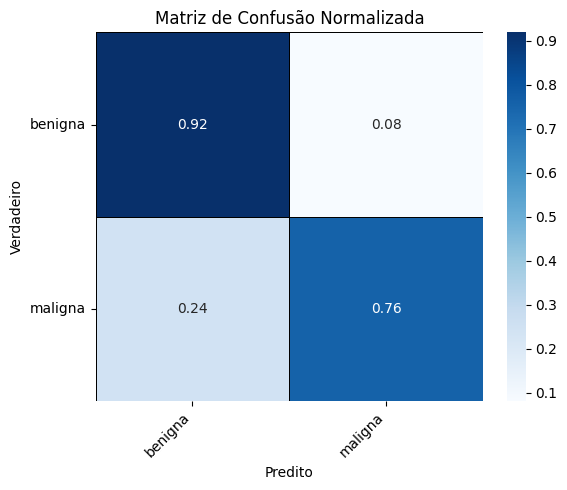

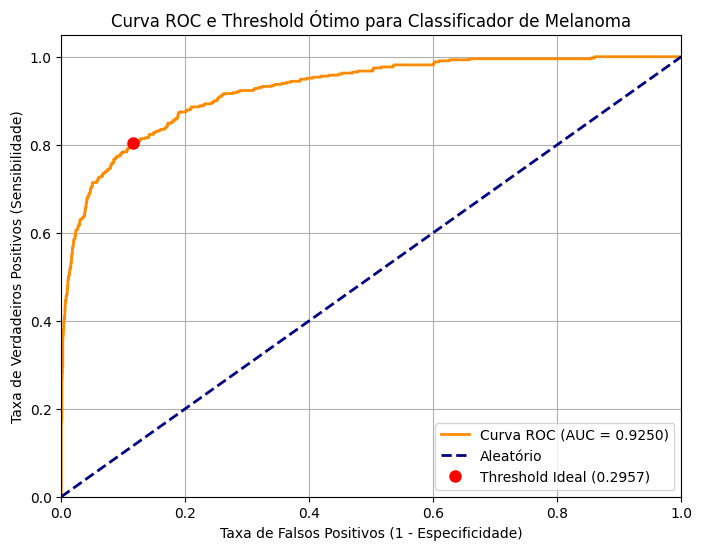

In [26]:
val_pred_proba, val_pred, val_bal_acc, val_report = predict_and_evaluate(model, val_batches, y_val)
optimal_threshold, roc_auc = plot_roc_curve(y_val, val_pred_proba)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step
Balanced Accuracy: 0.8431917762049208
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      2070
           1       0.59      0.80      0.68       430

    accuracy                           0.87      2500
   macro avg       0.77      0.84      0.80      2500
weighted avg       0.89      0.87      0.88      2500



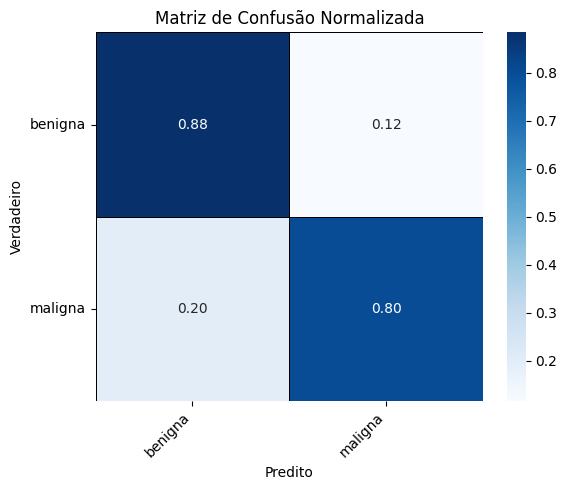

In [27]:
val_pred_proba, val_pred, val_bal_acc, val_report = predict_and_evaluate(model, val_batches, y_val, optimal_threshold)